# Rappi Restaurant Partners — Business Standing Analysis

**Objective:** Understand where the business stands right now across the restaurant partner portfolio.  
Key questions:
- What is the overall health of our restaurant portfolio?
- How are KPIs distributed (ratings, cancellations, delivery time, orders)?
- Which cities and verticals are performing best/worst?
- Which restaurants need immediate attention?
- How are KAMs managing their portfolios?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("dataset.csv", encoding="utf-8-sig")
print(f"Dataset: {df.shape[0]} restaurants × {df.shape[1]} columns")
df.head()

Dataset: 200 restaurants × 18 columns


,restaurant_id,nombre,ciudad,vertical,rating_actual,rating_prom_30d,delta_rating,tasa_cancelacion_pct,tiempo_entrega_avg_min,ordenes_7d,ordenes_7d_anterior,var_ordenes_pct,quejas_7d,nps_score,valor_ticket_prom_mxn,kam_asignado,activo_desde,semaforo_riesgo
0,R0005,El Asadero El Portal,Bogotá,Mercado,3.3,3.6,-0.31,15.5,43,111,123,-9.7,8,51,171.89,Ana Torres,2025-06-13,🟡 EN RIESGO
1,R0054,Burritos Gourmet,Barranquilla,Farmacia,4.1,4.1,-0.04,4.7,33,227,203,11.6,3,91,438.57,Ana Torres,2026-09-18,🟢 ESTABLE
2,R0059,Café Del Norte,Barranquilla,Farmacia,3.4,3.5,-0.07,20.4,57,60,68,-11.4,8,57,244.09,Ana Torres,2025-12-12,🟡 EN RIESGO
3,R0062,Tortas La Abuela,CDMX,Comida,2.5,3.1,-0.64,22.2,95,50,64,-21.4,29,5,149.40,Ana Torres,2024-06-03,🔴 CRÍTICO
4,R0074,Tortas Gourmet,Querétaro,Comida,3.6,3.8,-0.19,13.3,39,46,52,-11.9,17,35,137.59,Ana Torres,2024-11-25,🟡 EN RIESGO


In [2]:
df.info()
print("\n")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   restaurant_id           200 non-null    str    
 1   nombre                  200 non-null    str    
 2   ciudad                  200 non-null    str    
 3   vertical                200 non-null    str    
 4   rating_actual           200 non-null    float64
 5   rating_prom_30d         200 non-null    float64
 6   delta_rating            200 non-null    float64
 7   tasa_cancelacion_pct    200 non-null    float64
 8   tiempo_entrega_avg_min  200 non-null    int64  
 9   ordenes_7d              200 non-null    int64  
 10  ordenes_7d_anterior     200 non-null    int64  
 11  var_ordenes_pct         200 non-null    float64
 12  quejas_7d               200 non-null    int64  
 13  nps_score               200 non-null    int64  
 14  valor_ticket_prom_mxn   200 non-null    float64
 15  

,rating_actual,rating_prom_30d,delta_rating,tasa_cancelacion_pct,tiempo_entrega_avg_min,ordenes_7d,ordenes_7d_anterior,var_ordenes_pct,quejas_7d,nps_score,valor_ticket_prom_mxn
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,3.873000,3.965000,-0.089700,12.418500,39.965000,181.505000,177.035000,-4.533000,9.390000,59.920000,273.090950
std,0.933665,0.692439,0.281814,9.908902,17.378835,141.156885,127.531349,15.641602,10.603304,26.295071,118.272763
min,1.300000,2.100000,-0.890000,1.000000,18.000000,6.000000,7.000000,-42.900000,0.000000,0.000000,86.080000
25%,3.400000,3.600000,-0.262500,5.200000,27.000000,55.000000,67.000000,-15.725000,2.000000,41.750000,171.567500
50%,4.150000,4.100000,-0.045000,9.150000,36.000000,113.000000,124.000000,-3.700000,5.000000,68.000000,243.850000
75%,4.700000,4.525000,0.122500,17.550000,52.000000,305.250000,296.000000,8.025000,13.250000,83.000000,374.292500
max,5.000000,4.900000,0.300000,41.600000,95.000000,450.000000,471.000000,19.900000,45.000000,95.000000,519.370000


In [3]:
# Check for missing values
missing = df.isnull().sum()
missing[missing > 0] if missing.any() else print("No missing values ✓")

No missing values ✓


---
## 1. Portfolio Health Overview
How healthy is the overall restaurant portfolio right now?

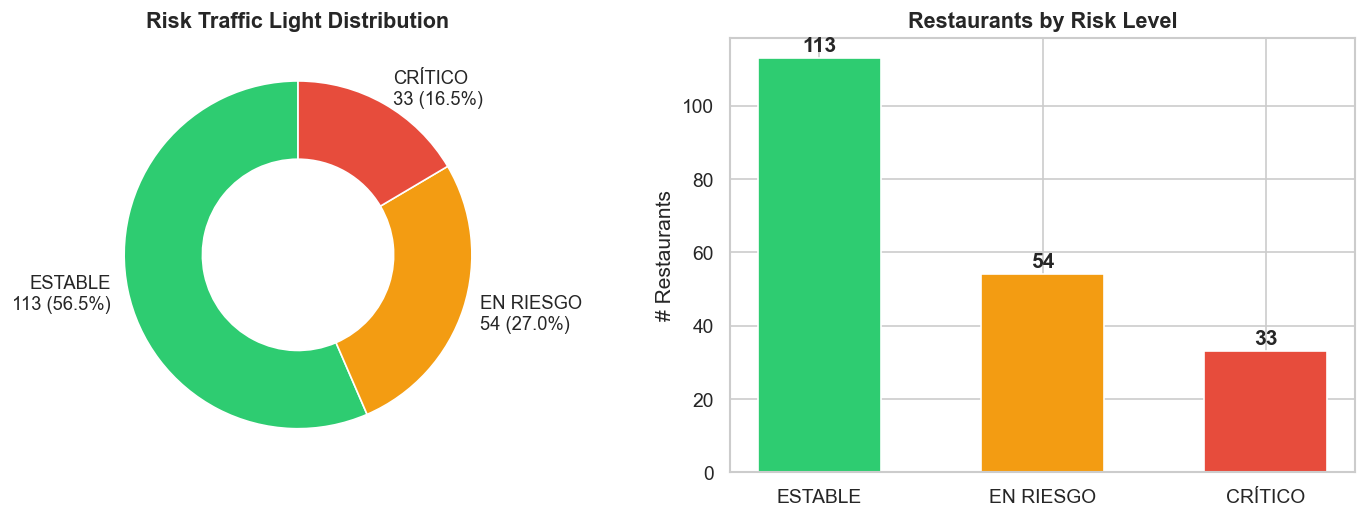


Summary: 56.5% stable, 27.0% at risk, 16.5% critical.


In [4]:
# Clean semaforo labels for easier handling
df["riesgo"] = df["semaforo_riesgo"].str.extract(r"(ESTABLE|EN RIESGO|CRÍTICO)")

risk_counts = df["riesgo"].value_counts()
risk_pct = (risk_counts / len(df) * 100).round(1)

color_map = {"ESTABLE": "#2ecc71", "EN RIESGO": "#f39c12", "CRÍTICO": "#e74c3c"}
order = ["ESTABLE", "EN RIESGO", "CRÍTICO"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Pie chart
axes[0].pie(
    [risk_counts[r] for r in order],
    labels=[f"{r}\n{risk_counts[r]} ({risk_pct[r]}%)" for r in order],
    colors=[color_map[r] for r in order],
    startangle=90, wedgeprops=dict(width=0.45, edgecolor="white"),
    textprops={"fontsize": 11}
)
axes[0].set_title("Risk Traffic Light Distribution", fontsize=13, fontweight="bold")

# Bar chart
bars = axes[1].bar(order, [risk_counts[r] for r in order], color=[color_map[r] for r in order], edgecolor="white", width=0.55)
for bar, r in zip(bars, order):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{risk_counts[r]}", ha="center", fontweight="bold")
axes[1].set_ylabel("# Restaurants")
axes[1].set_title("Restaurants by Risk Level", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nSummary: {risk_pct.get('ESTABLE', 0)}% stable, {risk_pct.get('EN RIESGO', 0)}% at risk, {risk_pct.get('CRÍTICO', 0)}% critical.")

---
## 2. KPI Snapshot — Where Do We Stand?
High-level view of the key operational metrics across the entire portfolio.

In [5]:
kpis = {
    "Avg Rating": df["rating_actual"].mean(),
    "Median Rating": df["rating_actual"].median(),
    "Avg Cancellation %": df["tasa_cancelacion_pct"].mean(),
    "Avg Delivery Time (min)": df["tiempo_entrega_avg_min"].mean(),
    "Total Orders (7d)": df["ordenes_7d"].sum(),
    "Avg Order Growth %": df["var_ordenes_pct"].mean(),
    "Total Complaints (7d)": df["quejas_7d"].sum(),
    "Avg NPS": df["nps_score"].mean(),
    "Avg Ticket (MXN)": df["valor_ticket_prom_mxn"].mean(),
}

kpi_df = pd.DataFrame.from_dict(kpis, orient="index", columns=["Value"])
kpi_df["Value"] = kpi_df["Value"].map(lambda x: f"{x:,.1f}")
kpi_df

,Value
Avg Rating,3.9
Median Rating,4.2
Avg Cancellation %,12.4
Avg Delivery Time (min),40.0
Total Orders (7d),"36,301.0"
Avg Order Growth %,-4.5
Total Complaints (7d),"1,878.0"
Avg NPS,59.9
Avg Ticket (MXN),273.1


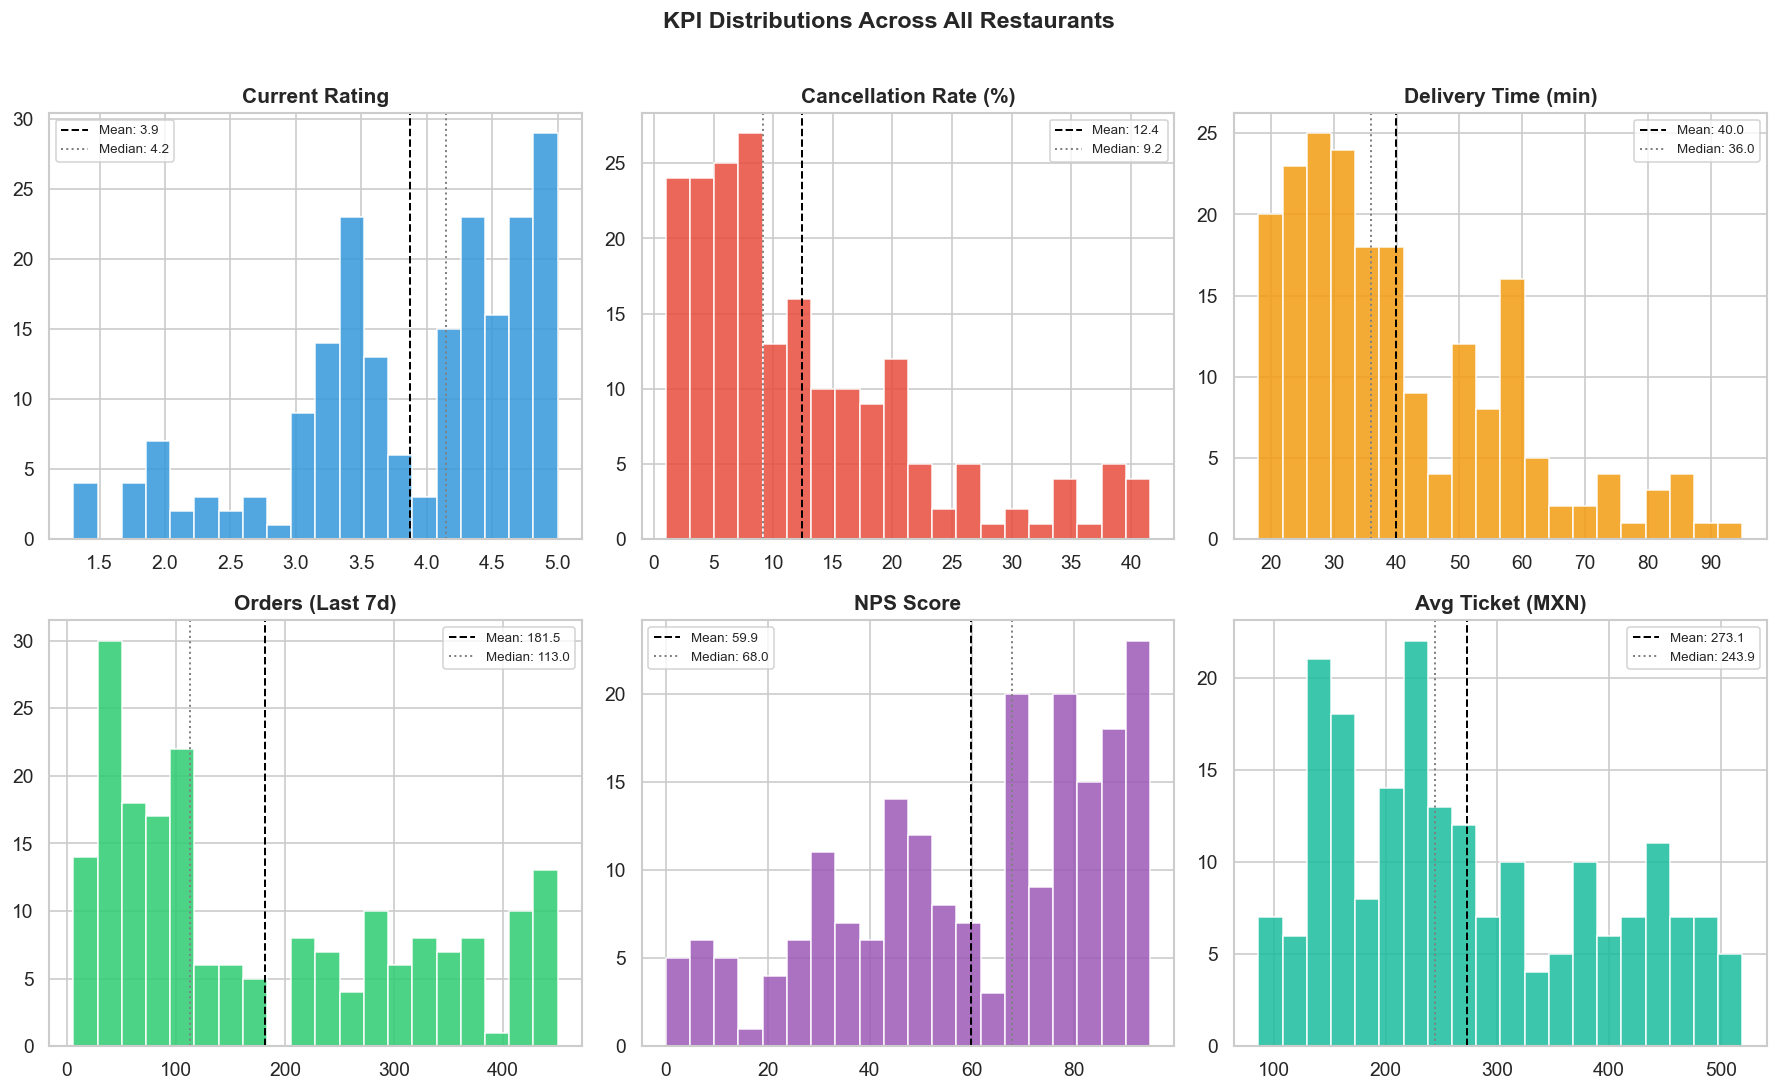

In [6]:
# Distribution of key metrics
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

metrics = [
    ("rating_actual", "Current Rating", "#3498db"),
    ("tasa_cancelacion_pct", "Cancellation Rate (%)", "#e74c3c"),
    ("tiempo_entrega_avg_min", "Delivery Time (min)", "#f39c12"),
    ("ordenes_7d", "Orders (Last 7d)", "#2ecc71"),
    ("nps_score", "NPS Score", "#9b59b6"),
    ("valor_ticket_prom_mxn", "Avg Ticket (MXN)", "#1abc9c"),
]

for ax, (col, title, color) in zip(axes.flat, metrics):
    ax.hist(df[col], bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(df[col].mean(), color="black", linestyle="--", linewidth=1.2, label=f"Mean: {df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="gray", linestyle=":", linewidth=1.2, label=f"Median: {df[col].median():.1f}")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("KPI Distributions Across All Restaurants", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 3. KPIs by Risk Level
How do key metrics differ between stable, at-risk, and critical restaurants?

In [7]:
risk_summary = df.groupby("riesgo").agg(
    count=("restaurant_id", "count"),
    avg_rating=("rating_actual", "mean"),
    avg_cancel_pct=("tasa_cancelacion_pct", "mean"),
    avg_delivery_min=("tiempo_entrega_avg_min", "mean"),
    avg_orders_7d=("ordenes_7d", "mean"),
    avg_order_growth=("var_ordenes_pct", "mean"),
    avg_complaints_7d=("quejas_7d", "mean"),
    avg_nps=("nps_score", "mean"),
    avg_ticket=("valor_ticket_prom_mxn", "mean"),
).reindex(["ESTABLE", "EN RIESGO", "CRÍTICO"]).round(1)

risk_summary

,count,avg_rating,avg_cancel_pct,avg_delivery_min,avg_orders_7d,avg_order_growth,avg_complaints_7d,avg_nps,avg_ticket
riesgo,,,,,,,,,
ESTABLE,113,4.5,5.7,28.6,277.1,6.7,2.7,79.4,346.6
EN RIESGO,54,3.4,15.5,47.4,72.1,-13.1,11.8,44.3,198.7
CRÍTICO,33,2.3,30.2,66.7,33.2,-28.8,28.2,18.8,143.0


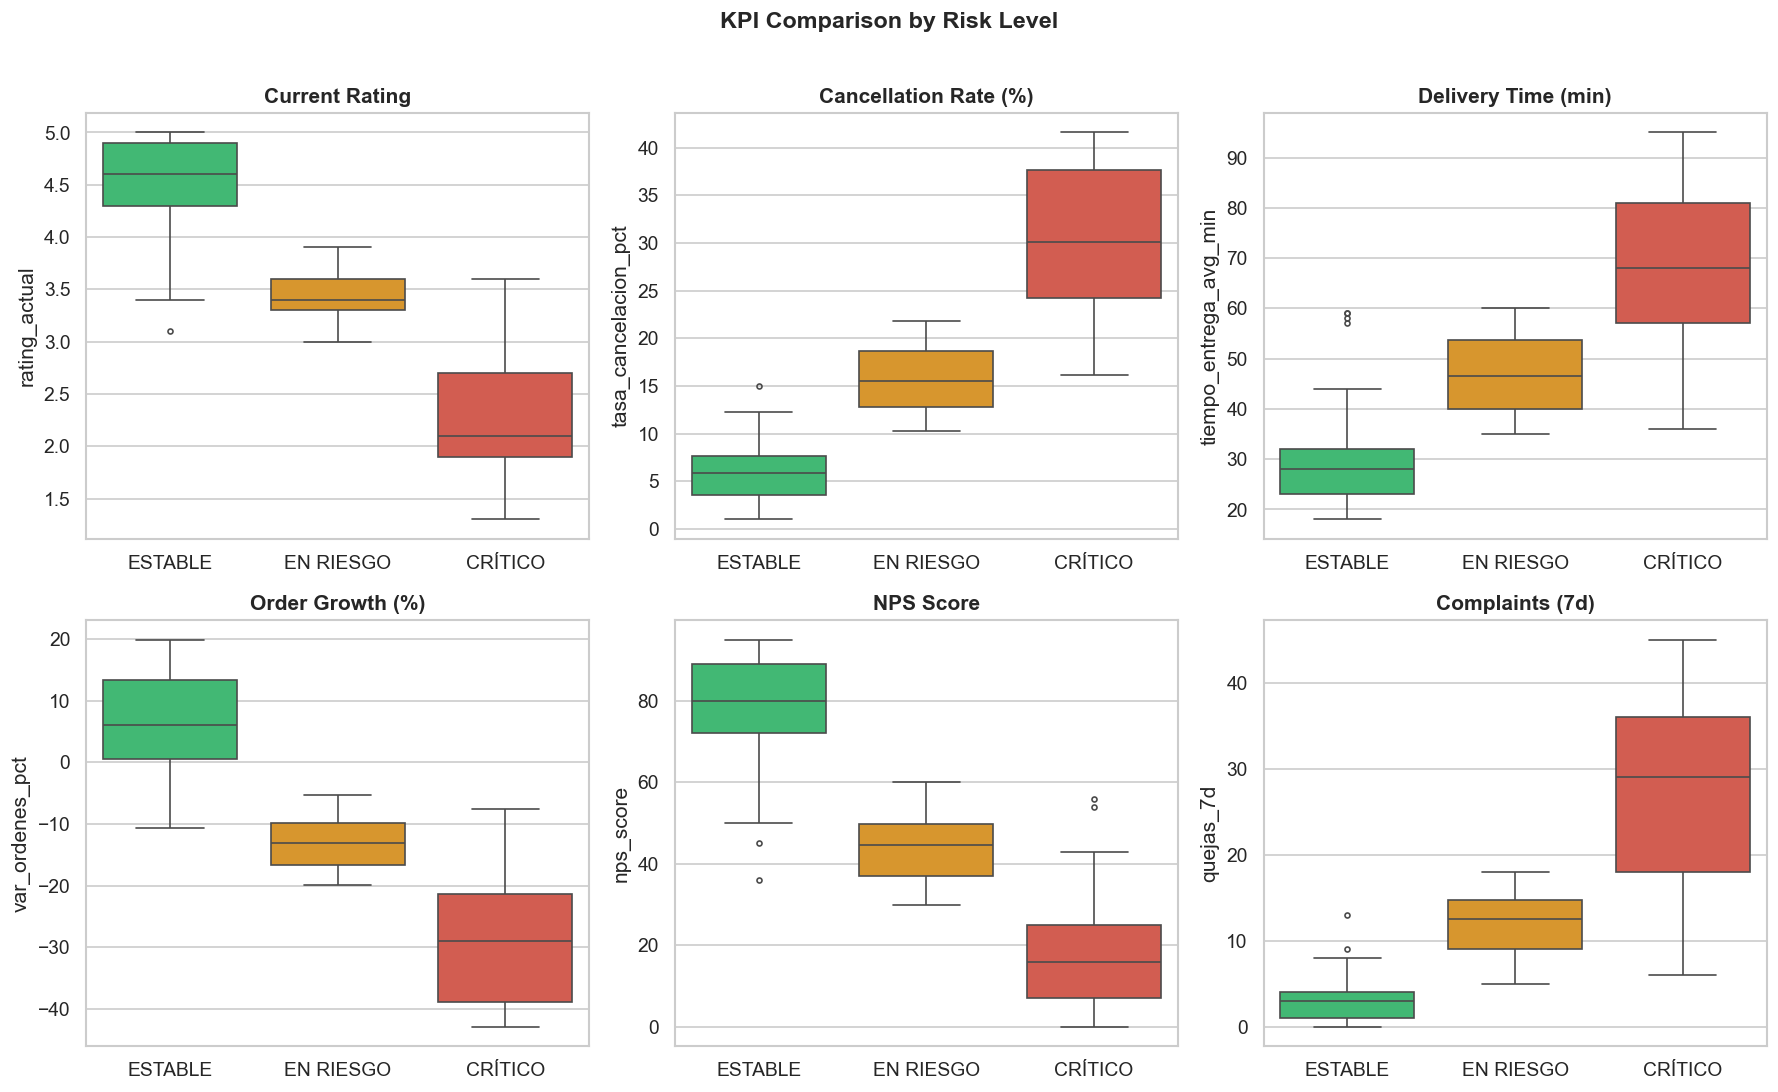

In [8]:
# Box plots: key metrics split by risk level
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

box_metrics = [
    ("rating_actual", "Current Rating"),
    ("tasa_cancelacion_pct", "Cancellation Rate (%)"),
    ("tiempo_entrega_avg_min", "Delivery Time (min)"),
    ("var_ordenes_pct", "Order Growth (%)"),
    ("nps_score", "NPS Score"),
    ("quejas_7d", "Complaints (7d)"),
]

palette = {"ESTABLE": "#2ecc71", "EN RIESGO": "#f39c12", "CRÍTICO": "#e74c3c"}

for ax, (col, title) in zip(axes.flat, box_metrics):
    sns.boxplot(data=df, x="riesgo", y=col, order=order, palette=palette, ax=ax, fliersize=3)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("")

plt.suptitle("KPI Comparison by Risk Level", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 4. City-Level Breakdown
Which cities are performing well and which need attention?

In [9]:
city_summary = df.groupby("ciudad").agg(
    restaurants=("restaurant_id", "count"),
    avg_rating=("rating_actual", "mean"),
    avg_cancel_pct=("tasa_cancelacion_pct", "mean"),
    avg_delivery_min=("tiempo_entrega_avg_min", "mean"),
    total_orders_7d=("ordenes_7d", "sum"),
    avg_order_growth=("var_ordenes_pct", "mean"),
    avg_nps=("nps_score", "mean"),
    pct_critical=("riesgo", lambda x: (x == "CRÍTICO").mean() * 100),
).round(1).sort_values("total_orders_7d", ascending=False)

city_summary

,restaurants,avg_rating,avg_cancel_pct,avg_delivery_min,total_orders_7d,avg_order_growth,avg_nps,pct_critical
ciudad,,,,,,,,
CDMX,37,4.0,11.0,39.8,7343,-1.8,62.1,16.2
Lima,22,4.2,10.4,33.1,4718,0.0,67.7,9.1
Guadalajara,21,3.7,13.9,43.7,3656,-6.6,58.7,19.0
Bogotá,23,3.7,15.0,43.4,3417,-8.6,49.5,26.1
Tijuana,15,3.8,12.4,37.7,2876,-3.6,60.5,26.7
Barranquilla,8,4.1,9.5,31.8,1914,1.0,73.2,0.0
Santiago,7,4.1,11.0,36.7,1854,-1.6,71.9,14.3
São Paulo,9,4.0,11.5,41.4,1736,-4.9,63.3,22.2
Querétaro,11,3.9,13.9,33.7,1623,-6.2,61.2,9.1


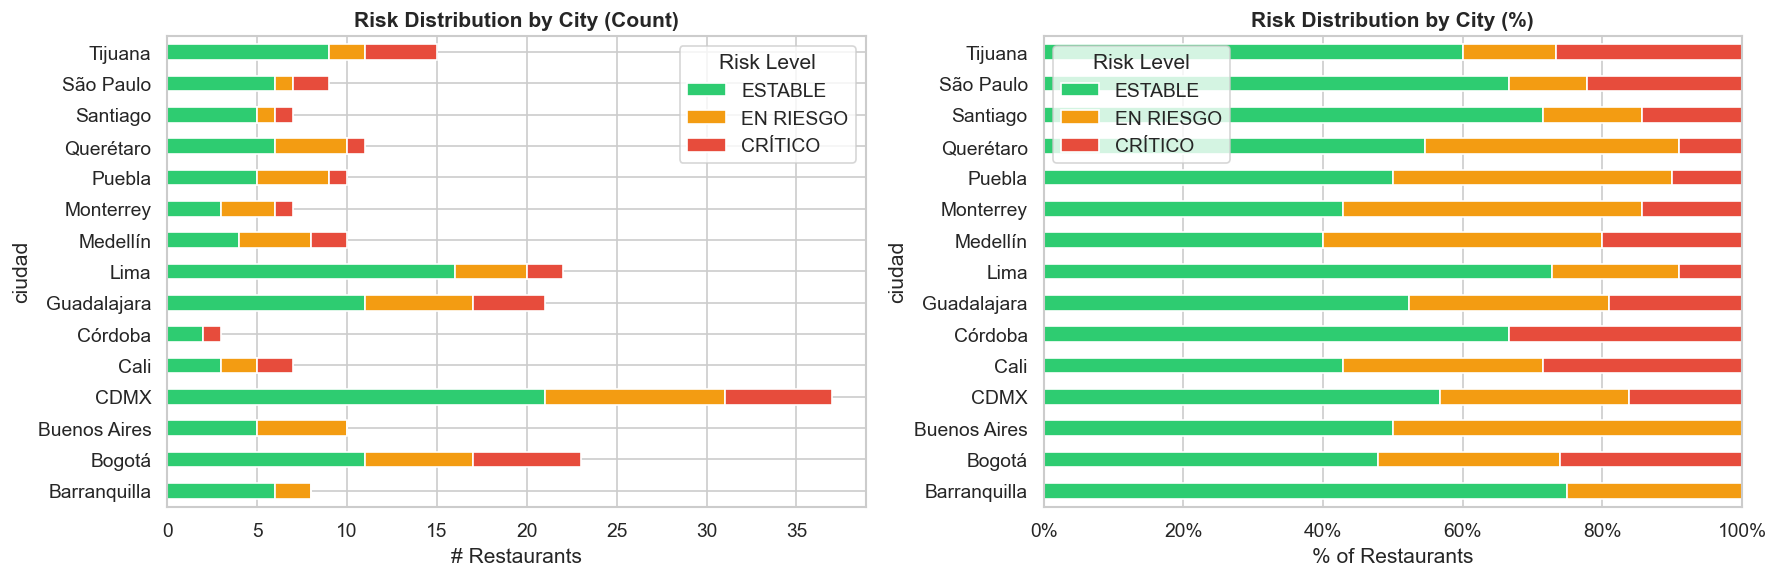

In [10]:
# Risk distribution by city
city_risk = pd.crosstab(df["ciudad"], df["riesgo"])[order]
city_risk_pct = city_risk.div(city_risk.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stacked bar (absolute)
city_risk.plot(kind="barh", stacked=True, color=[color_map[r] for r in order], ax=axes[0], edgecolor="white")
axes[0].set_title("Risk Distribution by City (Count)", fontweight="bold")
axes[0].set_xlabel("# Restaurants")
axes[0].legend(title="Risk Level")

# Stacked bar (percentage)
city_risk_pct.plot(kind="barh", stacked=True, color=[color_map[r] for r in order], ax=axes[1], edgecolor="white")
axes[1].set_title("Risk Distribution by City (%)", fontweight="bold")
axes[1].set_xlabel("% of Restaurants")
axes[1].legend(title="Risk Level")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

---
## 5. Vertical Breakdown
How is each business vertical (Comida, Farmacia, Bebidas, Mercado) performing?

In [11]:
vertical_summary = df.groupby("vertical").agg(
    restaurants=("restaurant_id", "count"),
    avg_rating=("rating_actual", "mean"),
    avg_cancel_pct=("tasa_cancelacion_pct", "mean"),
    avg_delivery_min=("tiempo_entrega_avg_min", "mean"),
    total_orders_7d=("ordenes_7d", "sum"),
    avg_order_growth=("var_ordenes_pct", "mean"),
    avg_nps=("nps_score", "mean"),
    avg_ticket=("valor_ticket_prom_mxn", "mean"),
    pct_critical=("riesgo", lambda x: (x == "CRÍTICO").mean() * 100),
).round(1).sort_values("total_orders_7d", ascending=False)

vertical_summary

,restaurants,avg_rating,avg_cancel_pct,avg_delivery_min,total_orders_7d,avg_order_growth,avg_nps,avg_ticket,pct_critical
vertical,,,,,,,,,
Comida,127,3.9,12.2,39.8,23394,-4.6,59.6,273.7,15.7
Farmacia,27,3.9,11.6,41.2,4897,-4.0,61.6,259.6,14.8
Bebidas,24,3.7,15.8,39.4,4282,-4.8,55.0,264.0,29.2
Mercado,22,4.0,11.1,40.1,3728,-4.3,65.0,296.3,9.1


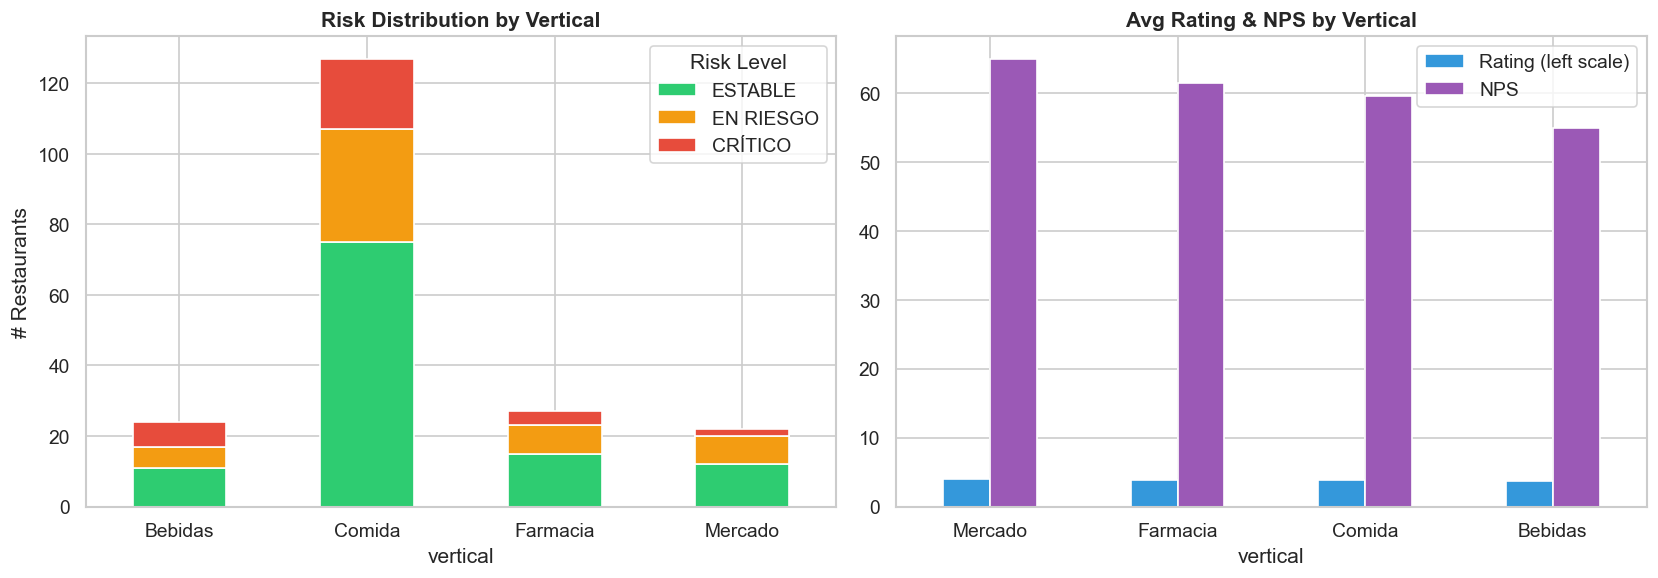

In [12]:
# Vertical risk distribution + avg rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vert_risk = pd.crosstab(df["vertical"], df["riesgo"])[order]
vert_risk.plot(kind="bar", stacked=True, color=[color_map[r] for r in order], ax=axes[0], edgecolor="white")
axes[0].set_title("Risk Distribution by Vertical", fontweight="bold")
axes[0].set_ylabel("# Restaurants")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title="Risk Level")

# Avg rating & NPS by vertical
vert_metrics = df.groupby("vertical")[["rating_actual", "nps_score"]].mean().sort_values("rating_actual", ascending=False)
vert_metrics.plot(kind="bar", ax=axes[1], color=["#3498db", "#9b59b6"], edgecolor="white")
axes[1].set_title("Avg Rating & NPS by Vertical", fontweight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(["Rating (left scale)", "NPS"])

plt.tight_layout()
plt.show()

---
## 6. Critical Restaurants — Immediate Attention List
Which restaurants are flagged as critical and what are their key pain points?

In [13]:
critical = df[df["riesgo"] == "CRÍTICO"].sort_values("rating_actual")

critical_display = critical[[
    "restaurant_id", "nombre", "ciudad", "vertical", "rating_actual",
    "delta_rating", "tasa_cancelacion_pct", "tiempo_entrega_avg_min",
    "ordenes_7d", "var_ordenes_pct", "quejas_7d", "nps_score", "kam_asignado"
]].reset_index(drop=True)

print(f"🔴 {len(critical)} critical restaurants requiring immediate attention:\n")
critical_display

🔴 33 critical restaurants requiring immediate attention:



,restaurant_id,nombre,ciudad,vertical,rating_actual,delta_rating,tasa_cancelacion_pct,tiempo_entrega_avg_min,ordenes_7d,var_ordenes_pct,quejas_7d,nps_score,kam_asignado
0,R0013,Tortas La Familia 2,Bogotá,Comida,1.3,-0.76,34.7,68,39,-41.4,44,28,Roberto Sánchez
1,R0125,La Cocina de La Plaza,Guadalajara,Comida,1.3,-0.89,26.9,64,31,-26.4,28,16,Roberto Sánchez
2,R0085,Tortas El Rey,Lima,Comida,1.3,-0.78,40.8,63,21,-37.2,18,0,Paula Herrera
3,R0048,Sushi La Plaza,CDMX,Comida,1.4,-0.75,32.3,81,43,-28.9,34,7,Paula Herrera
4,R0076,El Fogón Casero,Guadalajara,Comida,1.7,-0.43,39.1,88,24,-32.6,45,0,Roberto Sánchez
5,R0021,Parrilla La Abuela,Puebla,Comida,1.8,-0.37,25.8,61,40,-40.8,24,19,Diego Vargas
6,R0177,La Cocina de El Torito,Guadalajara,Bebidas,1.8,-0.38,25.5,75,20,-24.4,36,12,Fernando Castro
7,R0056,Los Tacos de Clásico,Tijuana,Comida,1.8,-0.88,33.9,70,50,-40.7,32,0,Carlos Mendoza
8,R0104,Burger Clásico,Tijuana,Farmacia,1.9,-0.79,23.0,84,7,-37.1,16,25,Ana Torres
9,R0155,La Cocina de La Familia 6,Bogotá,Comida,1.9,-0.88,40.4,75,6,-19.0,33,4,Paula Herrera


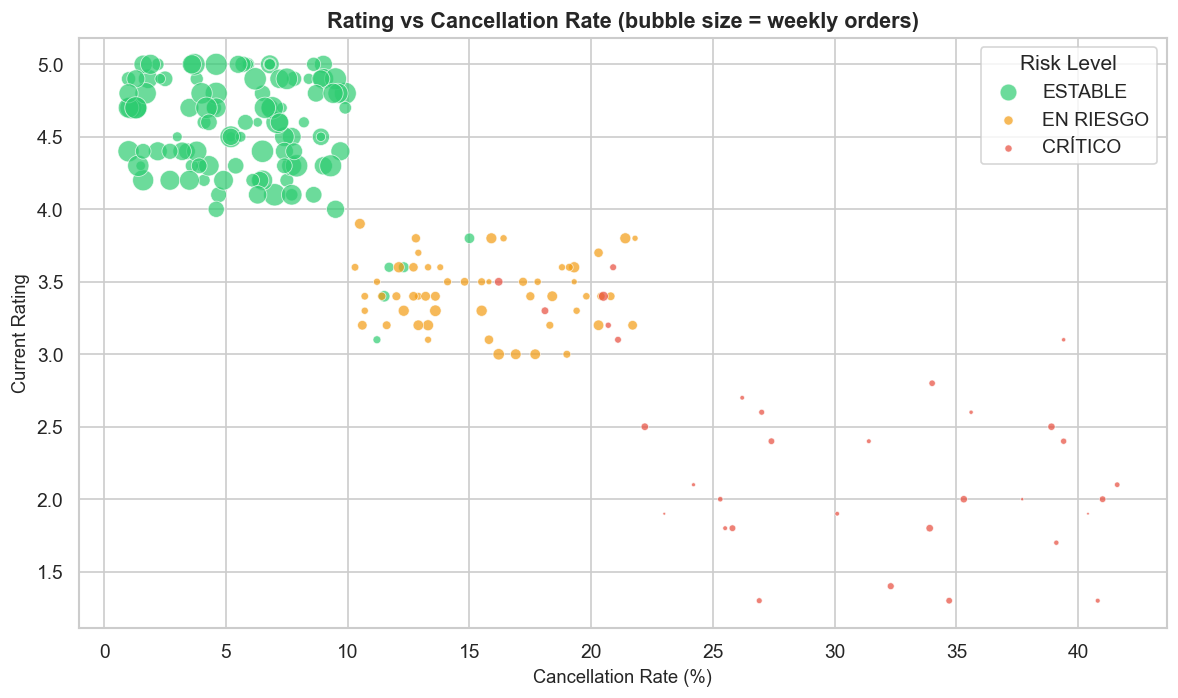

In [14]:
# What makes critical restaurants different? Scatter: cancellation rate vs rating colored by risk
fig, ax = plt.subplots(figsize=(10, 6))

for risk in order:
    subset = df[df["riesgo"] == risk]
    ax.scatter(
        subset["tasa_cancelacion_pct"], subset["rating_actual"],
        c=color_map[risk], label=risk, alpha=0.7, s=subset["ordenes_7d"] * 0.4,
        edgecolors="white", linewidth=0.5
    )

ax.set_xlabel("Cancellation Rate (%)", fontsize=11)
ax.set_ylabel("Current Rating", fontsize=11)
ax.set_title("Rating vs Cancellation Rate (bubble size = weekly orders)", fontsize=13, fontweight="bold")
ax.legend(title="Risk Level")
plt.tight_layout()
plt.show()

---
## 7. KAM Portfolio Performance
How are the Key Account Managers performing across their restaurant portfolios?

In [15]:
kam_summary = df.groupby("kam_asignado").agg(
    restaurants=("restaurant_id", "count"),
    avg_rating=("rating_actual", "mean"),
    total_orders_7d=("ordenes_7d", "sum"),
    avg_order_growth=("var_ordenes_pct", "mean"),
    avg_cancel_pct=("tasa_cancelacion_pct", "mean"),
    avg_nps=("nps_score", "mean"),
    total_complaints=("quejas_7d", "sum"),
    n_critical=("riesgo", lambda x: (x == "CRÍTICO").sum()),
    n_at_risk=("riesgo", lambda x: (x == "EN RIESGO").sum()),
    n_stable=("riesgo", lambda x: (x == "ESTABLE").sum()),
).round(1).sort_values("avg_rating", ascending=False)

kam_summary

,restaurants,avg_rating,total_orders_7d,avg_order_growth,avg_cancel_pct,avg_nps,total_complaints,n_critical,n_at_risk,n_stable
kam_asignado,,,,,,,,,,
María López,15,4.3,3123,-0.7,7.7,72.3,81,0,5,10
Juan Pérez,22,4.1,4859,-2.8,11.6,64.1,163,2,5,15
Fernando Castro,16,4.0,3323,-2.5,9.8,64.1,106,1,5,10
Isabella Moreno,25,4.0,4848,-3.2,12.1,63.6,224,2,8,15
Sofía Ramírez,20,3.9,3430,-6.3,13.2,61.6,200,4,5,11
Carlos Mendoza,15,3.8,2608,-7.6,14.3,57.2,170,4,4,7
Diego Vargas,22,3.8,4056,-3.9,12.1,59.0,193,4,5,13
Ana Torres,18,3.7,2155,-5.9,13.2,53.6,192,4,6,8
Paula Herrera,20,3.7,3712,-4.9,14.1,55.2,194,5,4,11


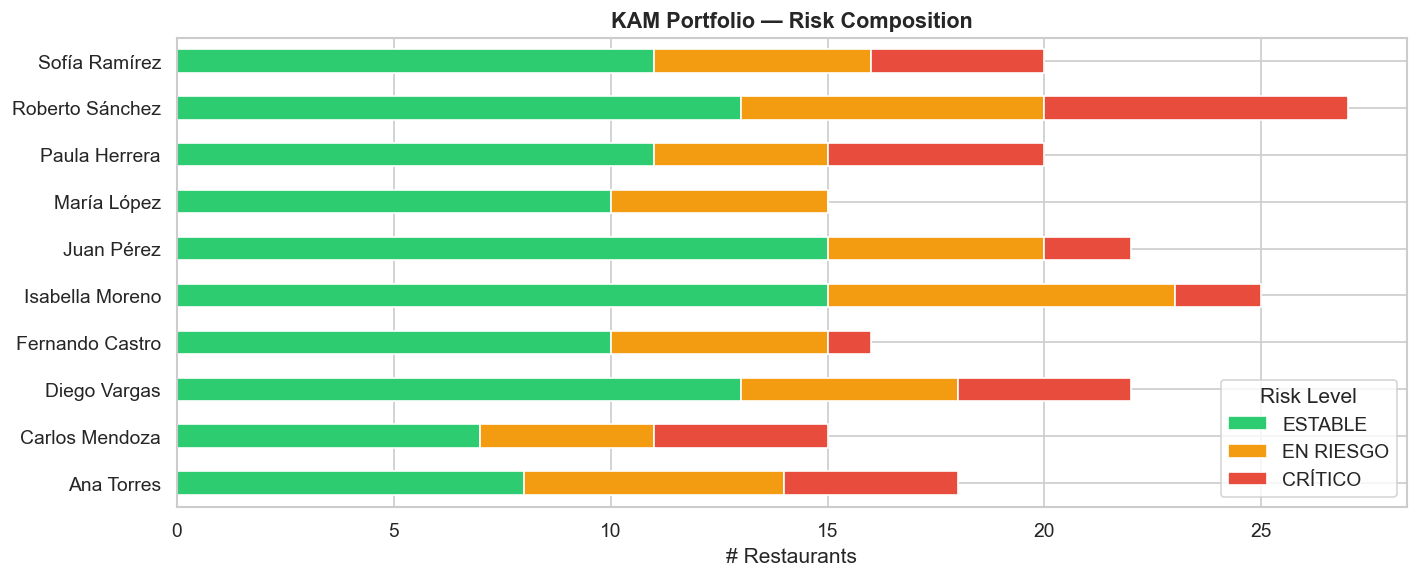

In [16]:
# KAM risk composition
fig, ax = plt.subplots(figsize=(12, 5))

kam_risk = pd.crosstab(df["kam_asignado"], df["riesgo"])[order]
kam_risk.plot(kind="barh", stacked=True, color=[color_map[r] for r in order], ax=ax, edgecolor="white")
ax.set_title("KAM Portfolio — Risk Composition", fontsize=13, fontweight="bold")
ax.set_xlabel("# Restaurants")
ax.set_ylabel("")
ax.legend(title="Risk Level")
plt.tight_layout()
plt.show()

---
## 8. Order Volume & Growth Trends
Which restaurants are growing vs declining? Is the overall portfolio trending up or down?

Total orders this week:  36,301
Total orders last week:  35,407
Overall WoW growth:      +2.5%

Growing restaurants:  86 (43%)
Declining restaurants: 114 (57%)
Flat restaurants:     0


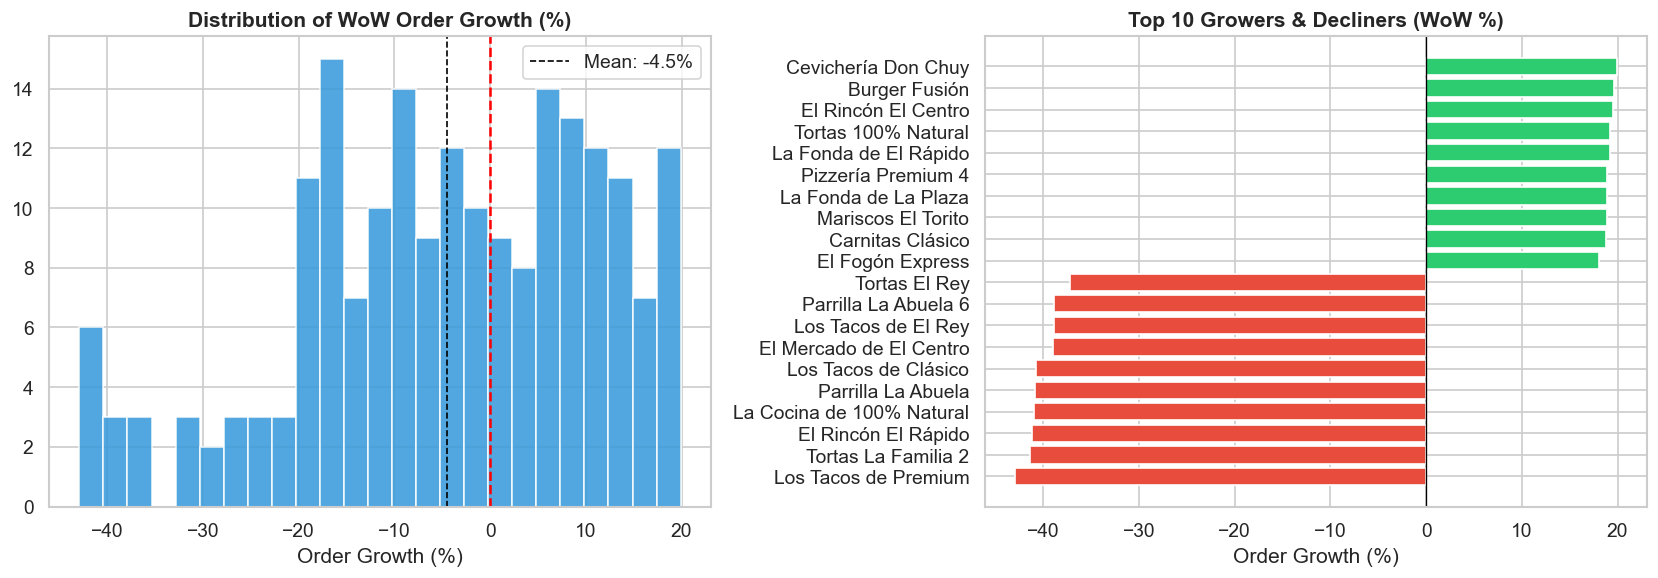

In [17]:
# Overall order volume change
total_orders_current = df["ordenes_7d"].sum()
total_orders_previous = df["ordenes_7d_anterior"].sum()
overall_growth = (total_orders_current - total_orders_previous) / total_orders_previous * 100

growing = (df["var_ordenes_pct"] > 0).sum()
declining = (df["var_ordenes_pct"] < 0).sum()
flat = (df["var_ordenes_pct"] == 0).sum()

print(f"Total orders this week:  {total_orders_current:,}")
print(f"Total orders last week:  {total_orders_previous:,}")
print(f"Overall WoW growth:      {overall_growth:+.1f}%")
print(f"\nGrowing restaurants:  {growing} ({growing/len(df)*100:.0f}%)")
print(f"Declining restaurants: {declining} ({declining/len(df)*100:.0f}%)")
print(f"Flat restaurants:     {flat}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of order growth
axes[0].hist(df["var_ordenes_pct"], bins=25, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].axvline(df["var_ordenes_pct"].mean(), color="black", linestyle="--", linewidth=1, label=f"Mean: {df['var_ordenes_pct'].mean():.1f}%")
axes[0].set_title("Distribution of WoW Order Growth (%)", fontweight="bold")
axes[0].set_xlabel("Order Growth (%)")
axes[0].legend()

# Top 15 growers vs top 15 decliners
top_grow = df.nlargest(10, "var_ordenes_pct")[["nombre", "var_ordenes_pct", "riesgo"]]
top_decline = df.nsmallest(10, "var_ordenes_pct")[["nombre", "var_ordenes_pct", "riesgo"]]
combined = pd.concat([top_grow, top_decline]).sort_values("var_ordenes_pct")

colors = [color_map.get(r, "#95a5a6") for r in combined["riesgo"]]
axes[1].barh(combined["nombre"], combined["var_ordenes_pct"], color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Top 10 Growers & Decliners (WoW %)", fontweight="bold")
axes[1].set_xlabel("Order Growth (%)")

plt.tight_layout()
plt.show()

---
## 9. Correlation Analysis
How do the key metrics relate to each other?

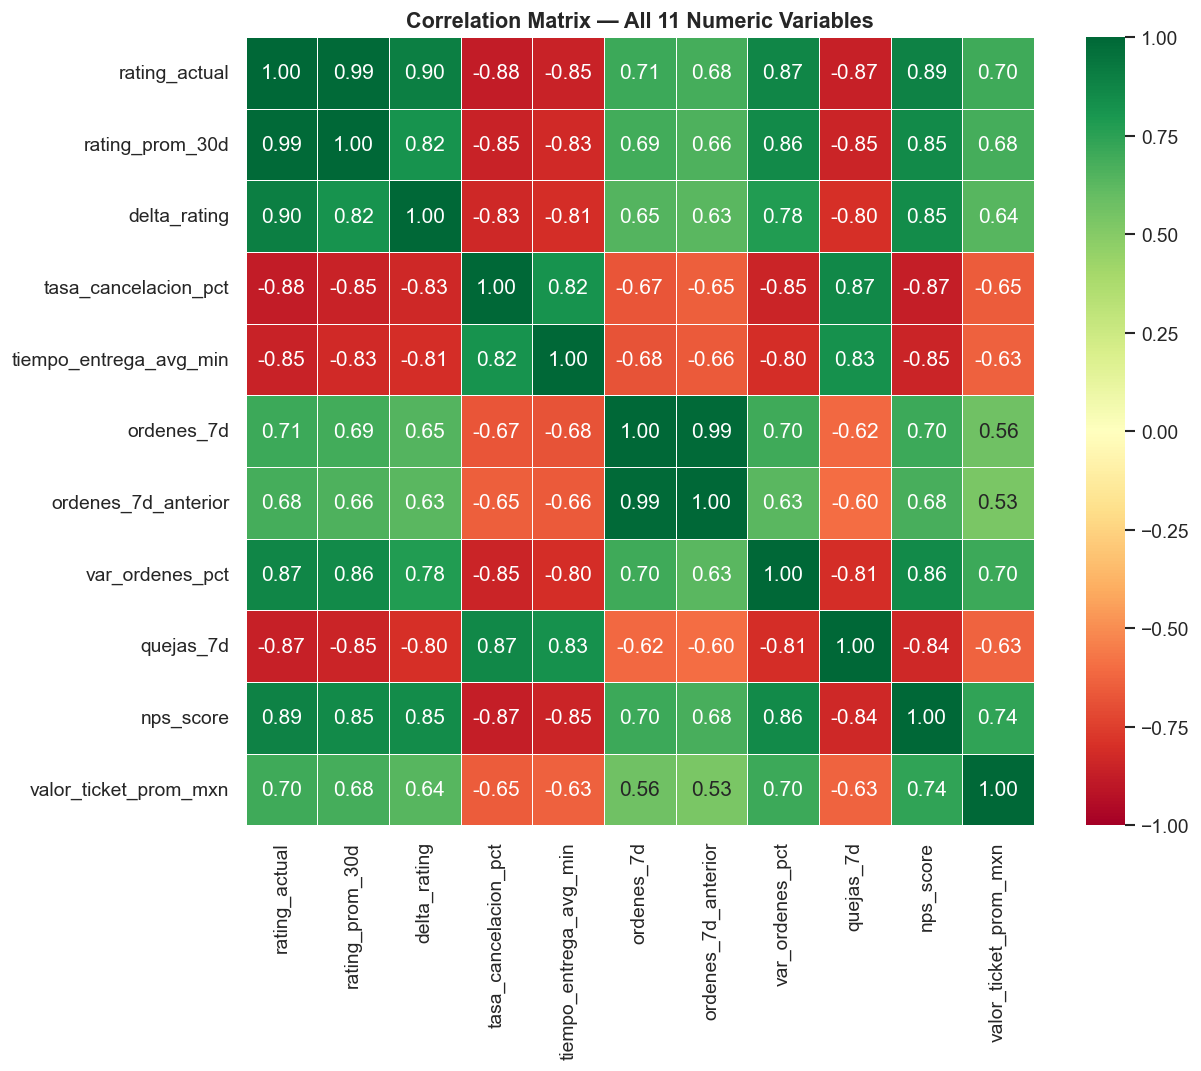

In [18]:
corr_cols = [
    "rating_actual", "rating_prom_30d", "delta_rating",
    "tasa_cancelacion_pct", "tiempo_entrega_avg_min",
    "ordenes_7d", "ordenes_7d_anterior", "var_ordenes_pct",
    "quejas_7d", "nps_score", "valor_ticket_prom_mxn"
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix — All 11 Numeric Variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 9b. Hierarchical Clustering on Variables
Using the correlation matrix as a distance measure **(1 − |r|)** to find clusters of redundant variables.  
The dendrogram lets you pick a threshold with stakeholders — then choose **one representative variable per cluster** based on which one the business actually acts on.

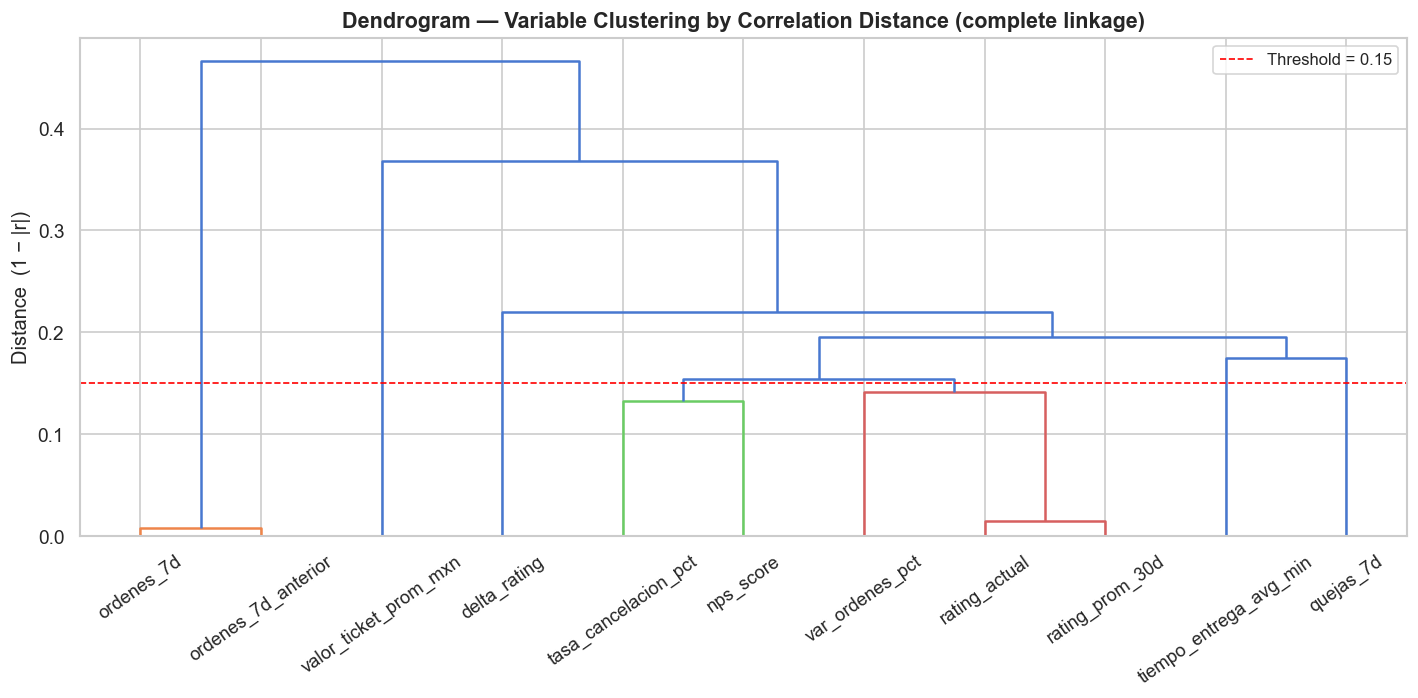

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# Distance matrix: 1 - |r|  (highly correlated variables cluster first)
dist_matrix = 1 - corr.abs()
condensed_dist = squareform(dist_matrix, checks=False)

# Complete linkage — produces cleaner, more interpretable clusters than single linkage
Z = linkage(condensed_dist, method="complete")

fig, ax = plt.subplots(figsize=(12, 6))
dn = dendrogram(
    Z,
    labels=corr_cols,
    ax=ax,
    leaf_rotation=35,
    leaf_font_size=11,
    color_threshold=0.15,
)
ax.set_ylabel("Distance  (1 − |r|)", fontsize=12)
ax.set_title("Dendrogram — Variable Clustering by Correlation Distance (complete linkage)",
             fontsize=13, fontweight="bold")
ax.axhline(y=0.15, color="red", linestyle="--", linewidth=1, label="Threshold = 0.15")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [21]:
# Cut the dendrogram at a chosen threshold to form clusters
threshold = 0.15  # <-- adjust this with stakeholders
cluster_labels = fcluster(Z, t=threshold, criterion="distance")

cluster_df = pd.DataFrame({
    "variable": corr_cols,
    "cluster": cluster_labels
}).sort_values("cluster")

print(f"Threshold = {threshold}  →  {cluster_df['cluster'].nunique()} clusters\n")

for cid in sorted(cluster_df["cluster"].unique()):
    members = cluster_df[cluster_df["cluster"] == cid]["variable"].tolist()
    print(f"  Cluster {cid}: {', '.join(members)}")

print("\n→ Pick one variable per cluster — the one the business actually acts on.")

Threshold = 0.15  →  7 clusters

  Cluster 1: ordenes_7d, ordenes_7d_anterior
  Cluster 2: tasa_cancelacion_pct, nps_score
  Cluster 3: rating_actual, rating_prom_30d, var_ordenes_pct
  Cluster 4: tiempo_entrega_avg_min
  Cluster 5: quejas_7d
  Cluster 6: delta_rating
  Cluster 7: valor_ticket_prom_mxn

→ Pick one variable per cluster — the one the business actually acts on.


---
## 10. Top & Bottom Performers
Quick reference: the best and worst restaurants across key metrics.

In [19]:
show_cols = ["nombre", "ciudad", "vertical", "rating_actual", "ordenes_7d", "tasa_cancelacion_pct", "nps_score", "riesgo"]

print("⭐ Top 10 by Rating")
display(df.nlargest(10, "rating_actual")[show_cols].reset_index(drop=True))

print("\n⚠️ Bottom 10 by Rating")
display(df.nsmallest(10, "rating_actual")[show_cols].reset_index(drop=True))

print("\n📦 Top 10 by Order Volume (7d)")
display(df.nlargest(10, "ordenes_7d")[show_cols].reset_index(drop=True))

print("\n🚨 Top 10 by Cancellation Rate")
display(df.nlargest(10, "tasa_cancelacion_pct")[show_cols + ["quejas_7d"]].reset_index(drop=True))

⭐ Top 10 by Rating


,nombre,ciudad,vertical,rating_actual,ordenes_7d,tasa_cancelacion_pct,nps_score,riesgo
0,El Fogón Artesanal 8,CDMX,Comida,5.0,292,9.0,76,ESTABLE
1,El Mercado de Clásico,Bogotá,Comida,5.0,159,5.9,68,ESTABLE
2,Sushi Del Barrio,São Paulo,Comida,5.0,109,5.9,81,ESTABLE
3,Tortas El Rápido 7,Bogotá,Farmacia,5.0,315,6.8,70,ESTABLE
4,Sushi Fusión 8,Guadalajara,Mercado,5.0,434,4.6,90,ESTABLE
5,El Mercado de El Rey,Buenos Aires,Comida,5.0,140,2.2,77,ESTABLE
6,Café El Portal,São Paulo,Comida,5.0,421,3.7,87,ESTABLE
7,Cevichería La Esquina,CDMX,Comida,5.0,146,6.8,91,ESTABLE
8,Café La Plaza 7,Puebla,Mercado,5.0,233,5.7,95,ESTABLE
9,Parrilla Casero,Guadalajara,Bebidas,5.0,303,1.6,92,ESTABLE



⚠️ Bottom 10 by Rating


,nombre,ciudad,vertical,rating_actual,ordenes_7d,tasa_cancelacion_pct,nps_score,riesgo
0,Tortas El Rey,Lima,Comida,1.3,21,40.8,0,CRÍTICO
1,Tortas La Familia 2,Bogotá,Comida,1.3,39,34.7,28,CRÍTICO
2,La Cocina de La Plaza,Guadalajara,Comida,1.3,31,26.9,16,CRÍTICO
3,Sushi La Plaza,CDMX,Comida,1.4,43,32.3,7,CRÍTICO
4,El Fogón Casero,Guadalajara,Comida,1.7,24,39.1,0,CRÍTICO
5,Los Tacos de Clásico,Tijuana,Comida,1.8,50,33.9,0,CRÍTICO
6,Parrilla La Abuela,Puebla,Comida,1.8,40,25.8,19,CRÍTICO
7,La Cocina de El Torito,Guadalajara,Bebidas,1.8,20,25.5,12,CRÍTICO
8,Burger Clásico,Tijuana,Farmacia,1.9,7,23.0,25,CRÍTICO
9,La Cocina de La Familia 6,Bogotá,Comida,1.9,6,40.4,4,CRÍTICO



📦 Top 10 by Order Volume (7d)


,nombre,ciudad,vertical,rating_actual,ordenes_7d,tasa_cancelacion_pct,nps_score,riesgo
0,Sushi La Esquina,CDMX,Comida,4.6,450,7.1,91,ESTABLE
1,Parrilla Del Norte,Tijuana,Comida,4.1,449,7.0,84,ESTABLE
2,Los Tacos de Don Chuy 9,Lima,Comida,4.9,449,6.2,70,ESTABLE
3,Sushi El Portal,CDMX,Farmacia,4.3,449,7.9,76,ESTABLE
4,El Fogón El Portal,Lima,Comida,4.7,449,6.9,79,ESTABLE
5,La Cocina de Premium,Cali,Comida,4.4,447,6.5,77,ESTABLE
6,Burger Don Chuy,Tijuana,Comida,4.7,441,1.3,67,ESTABLE
7,El Rincón La Familia,CDMX,Farmacia,4.8,438,4.6,85,ESTABLE
8,Parrilla Fusión,CDMX,Comida,4.7,437,1.1,69,ESTABLE
9,Tortas La Esquina 9,Bogotá,Comida,4.8,435,9.9,72,ESTABLE



🚨 Top 10 by Cancellation Rate


,nombre,ciudad,vertical,rating_actual,ordenes_7d,tasa_cancelacion_pct,nps_score,riesgo,quejas_7d
0,Pizzería La Abuela,Querétaro,Comida,2.1,27,41.6,11,CRÍTICO,36
1,Parrilla Gourmet,Guadalajara,Comida,2.0,39,41.0,21,CRÍTICO,26
2,Tortas El Rey,Lima,Comida,1.3,21,40.8,0,CRÍTICO,18
3,La Cocina de La Familia 6,Bogotá,Comida,1.9,6,40.4,4,CRÍTICO,33
4,Sushi Casero,Santiago,Bebidas,3.1,16,39.4,25,CRÍTICO,25
5,El Rincón Gourmet,Cali,Bebidas,2.4,34,39.4,12,CRÍTICO,36
6,El Fogón Casero,Guadalajara,Comida,1.7,24,39.1,0,CRÍTICO,45
7,El Mercado de El Portal,CDMX,Bebidas,2.5,48,38.9,28,CRÍTICO,36
8,El Rincón El Rápido,Medellín,Comida,2.0,9,37.7,7,CRÍTICO,45
9,Pizzería Fusión,São Paulo,Comida,2.6,16,35.6,20,CRÍTICO,45


---
## Summary

This notebook provides a current-state snapshot of the Rappi restaurant partner portfolio. Key areas to investigate further:

1. **Critical restaurants** — deep-dive into root causes (delivery issues? quality? cancellations?) and assign action plans per KAM
2. **City-specific strategies** — cities with high critical % may need market-level interventions
3. **Vertical performance gaps** — understand if underperformance is structural or operational
4. **KAM effectiveness** — identify best practices from top-performing KAMs and replicate
5. **Growth vs decline patterns** — understand what drives the top growers and stabilize decliners